In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

#Afficharge des données 

df = pd.read_csv('train.csv')
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [3]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [4]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

array([[<Axes: title={'center': 'battery_power'}>,
        <Axes: title={'center': 'blue'}>,
        <Axes: title={'center': 'clock_speed'}>,
        <Axes: title={'center': 'dual_sim'}>,
        <Axes: title={'center': 'fc'}>],
       [<Axes: title={'center': 'four_g'}>,
        <Axes: title={'center': 'int_memory'}>,
        <Axes: title={'center': 'm_dep'}>,
        <Axes: title={'center': 'mobile_wt'}>,
        <Axes: title={'center': 'n_cores'}>],
       [<Axes: title={'center': 'pc'}>,
        <Axes: title={'center': 'px_height'}>,
        <Axes: title={'center': 'px_width'}>,
        <Axes: title={'center': 'ram'}>,
        <Axes: title={'center': 'sc_h'}>],
       [<Axes: title={'center': 'sc_w'}>,
        <Axes: title={'center': 'talk_time'}>,
        <Axes: title={'center': 'three_g'}>,
        <Axes: title={'center': 'touch_screen'}>,
        <Axes: title={'center': 'wifi'}>],
       [<Axes: title={'center': 'price_range'}>, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >]], 

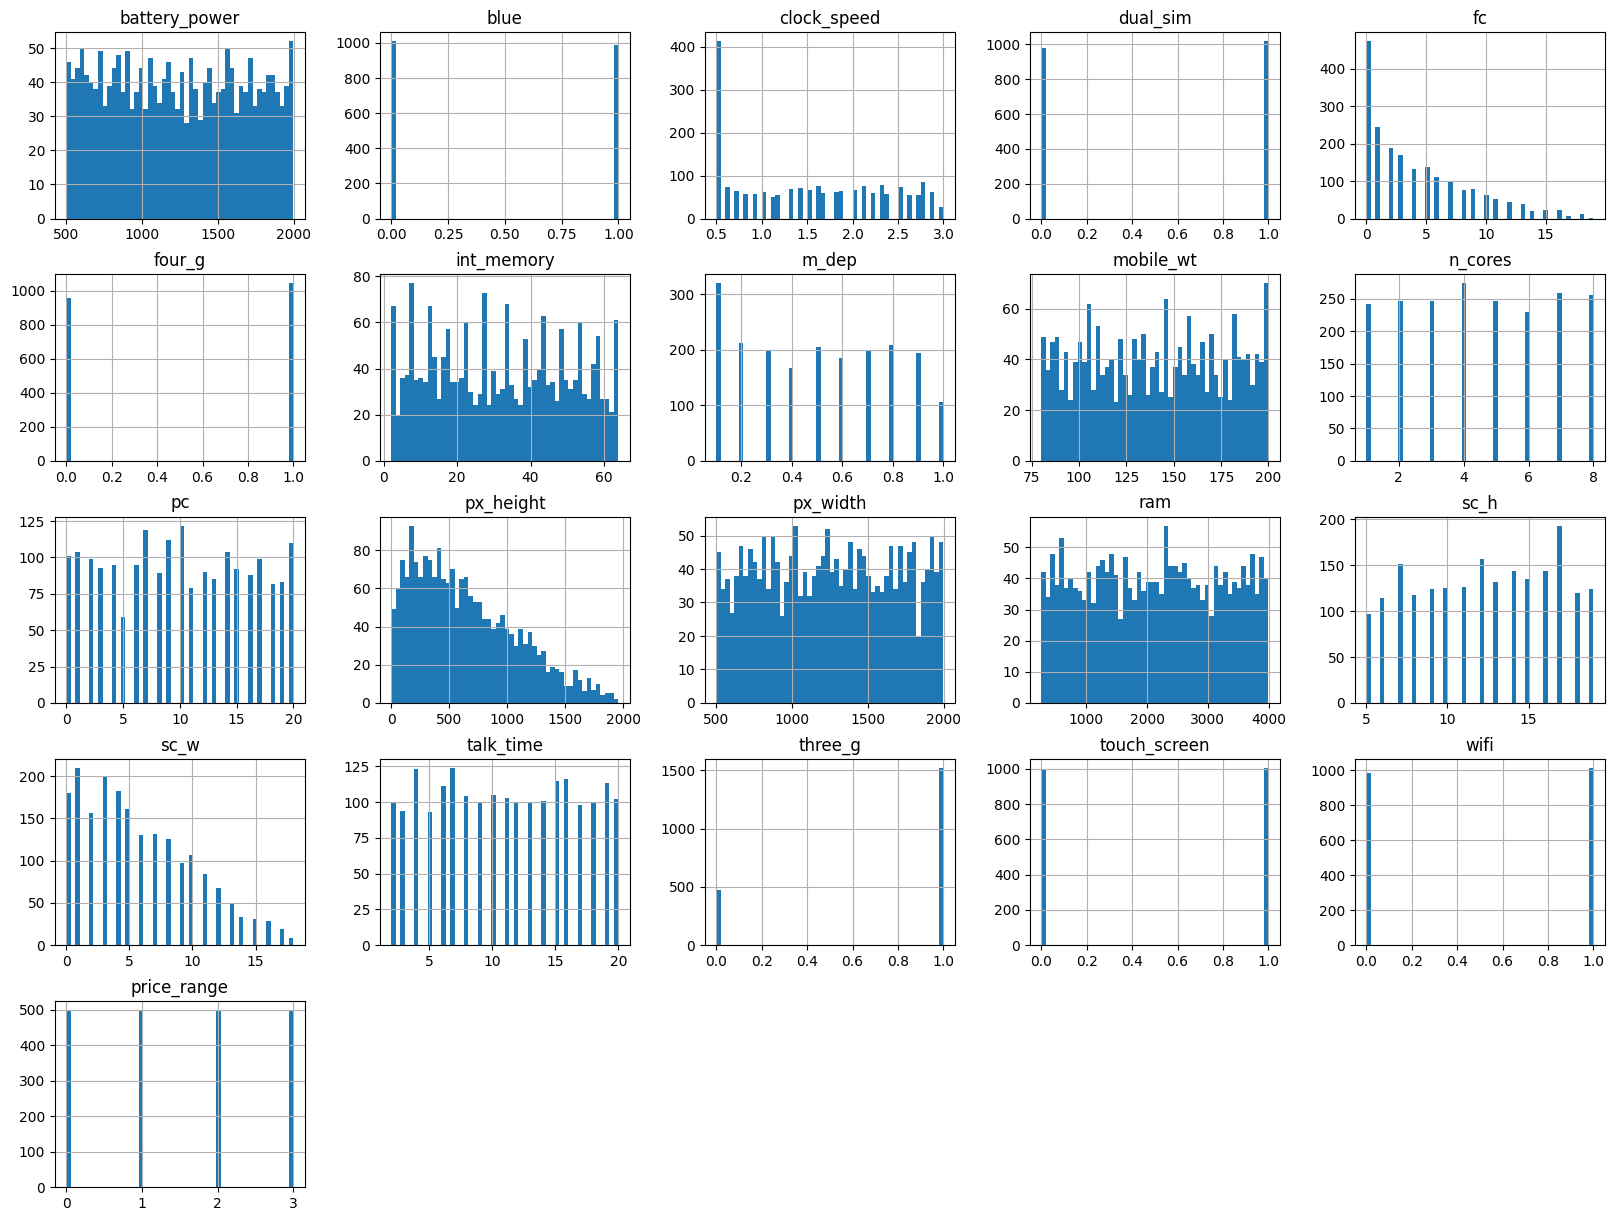

In [5]:
df.hist(bins=50, figsize=(20,15))

array([[<Axes: title={'center': 'battery_power'}>,
        <Axes: title={'center': 'ram'}>],
       [<Axes: title={'center': 'price_range'}>, <Axes: >]], dtype=object)

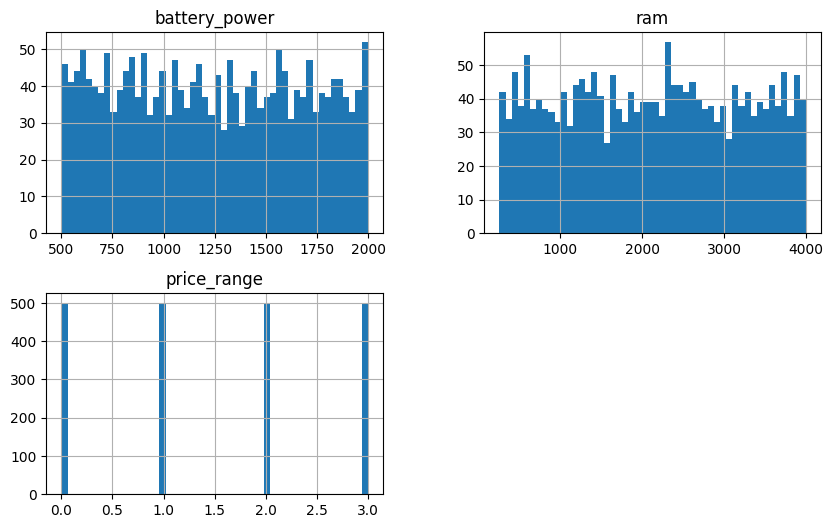

In [6]:
df[['battery_power', 'ram', 'price_range']].hist(bins=50, figsize=(10,6))

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['price_range'].value_counts().sort_index()

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

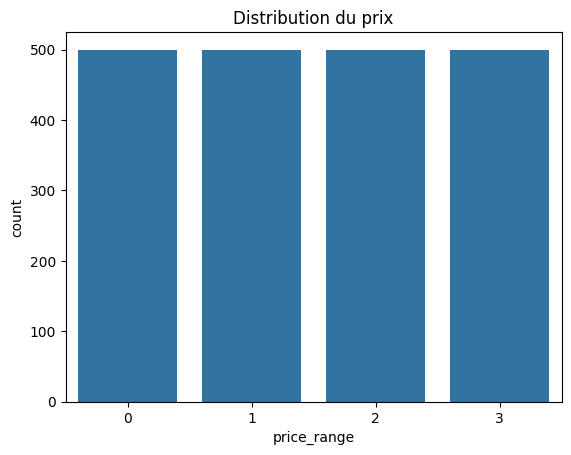

In [9]:
sns.countplot(x='price_range', data=df)
plt.title("Distribution du prix")
plt.show()

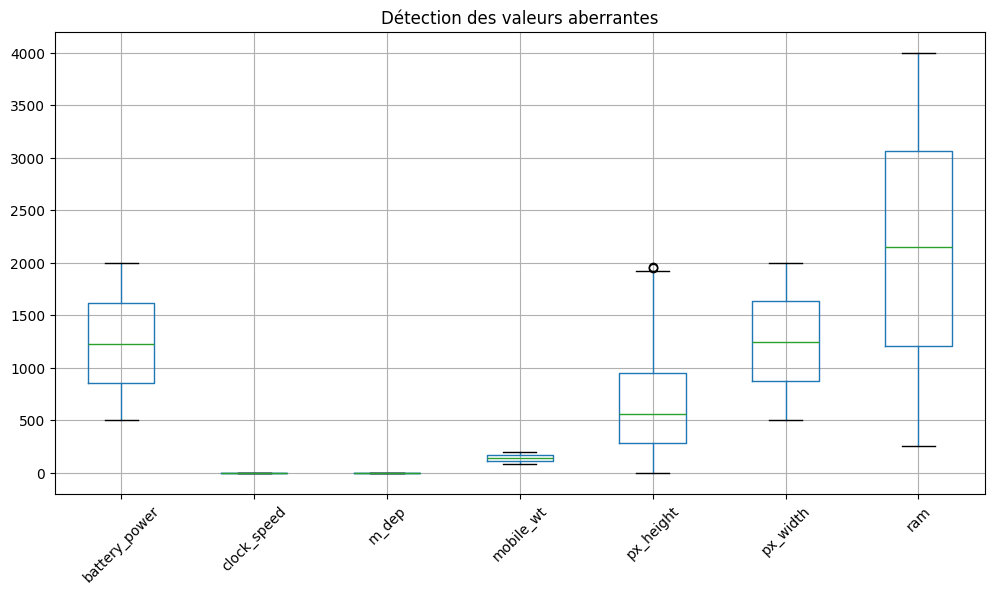

In [10]:
    ## Définition des variables par catégories
binary_cols = ['blue','dual_sim','four_g','three_g','touch_screen','wifi'] #binary values variables
continuous_cols = ['battery_power','clock_speed','m_dep','mobile_wt','px_height','px_width','ram']#long values variables
discrete_cols = ['fc','pc','n_cores','int_memory','sc_h','sc_w','talk_time'] #short values variables 

## Détection des valeurs aberrantes 
plt.figure(figsize=(12,6))
df[continuous_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Détection des valeurs aberrantes")
plt.show()

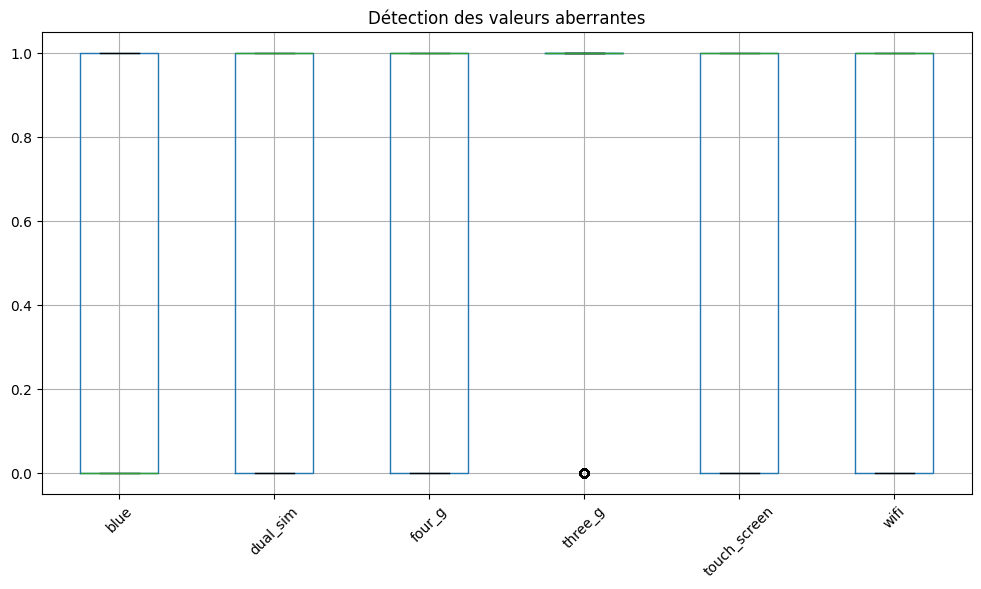

In [11]:
plt.figure(figsize=(12,6))
df[binary_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Détection des valeurs aberrantes")
plt.show()

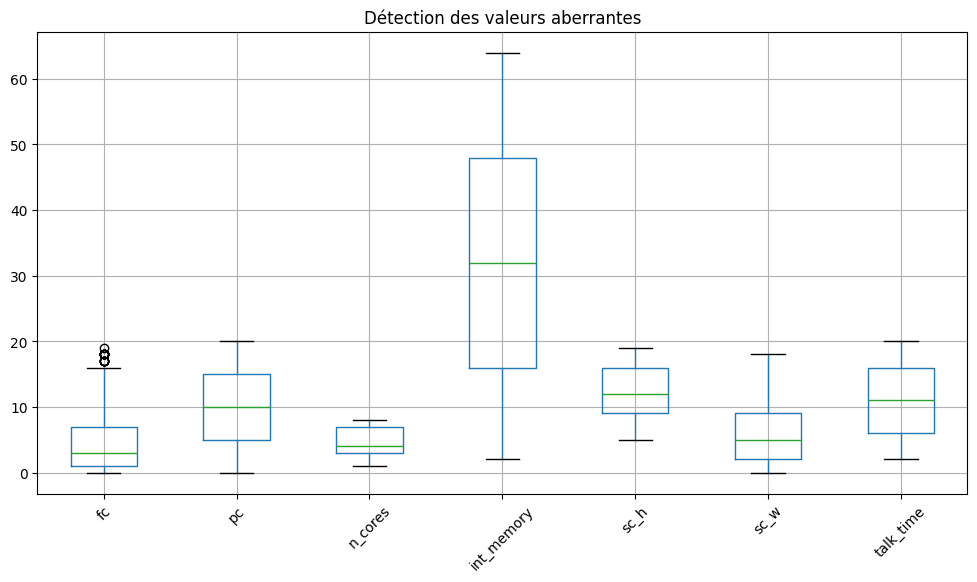

In [12]:
plt.figure(figsize=(12,6))
df[discrete_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Détection des valeurs aberrantes")
plt.show()

In [13]:
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    return ((data[col] < Q1 - 1.5*IQR) | 
            (data[col] > Q3 + 1.5*IQR)).sum()

for col in continuous_cols:
    print(col, ":", detect_outliers_iqr(df, col))

battery_power : 0
clock_speed : 0
m_dep : 0
mobile_wt : 0
px_height : 2
px_width : 0
ram : 0


In [14]:
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    return ((data[col] < Q1 - 1.5*IQR) | 
            (data[col] > Q3 + 1.5*IQR)).sum()

for col in binary_cols:
    print(col, ":", detect_outliers_iqr(df, col))


blue : 0
dual_sim : 0
four_g : 0
three_g : 477
touch_screen : 0
wifi : 0


In [15]:
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    return ((data[col] < Q1 - 1.5*IQR) | 
            (data[col] > Q3 + 1.5*IQR)).sum()

for col in discrete_cols:
    print(col, ":", detect_outliers_iqr(df, col))

fc : 18
pc : 0
n_cores : 0
int_memory : 0
sc_h : 0
sc_w : 0
talk_time : 0


In [16]:
df['three_g'].value_counts()

three_g
1    1523
0     477
Name: count, dtype: int64

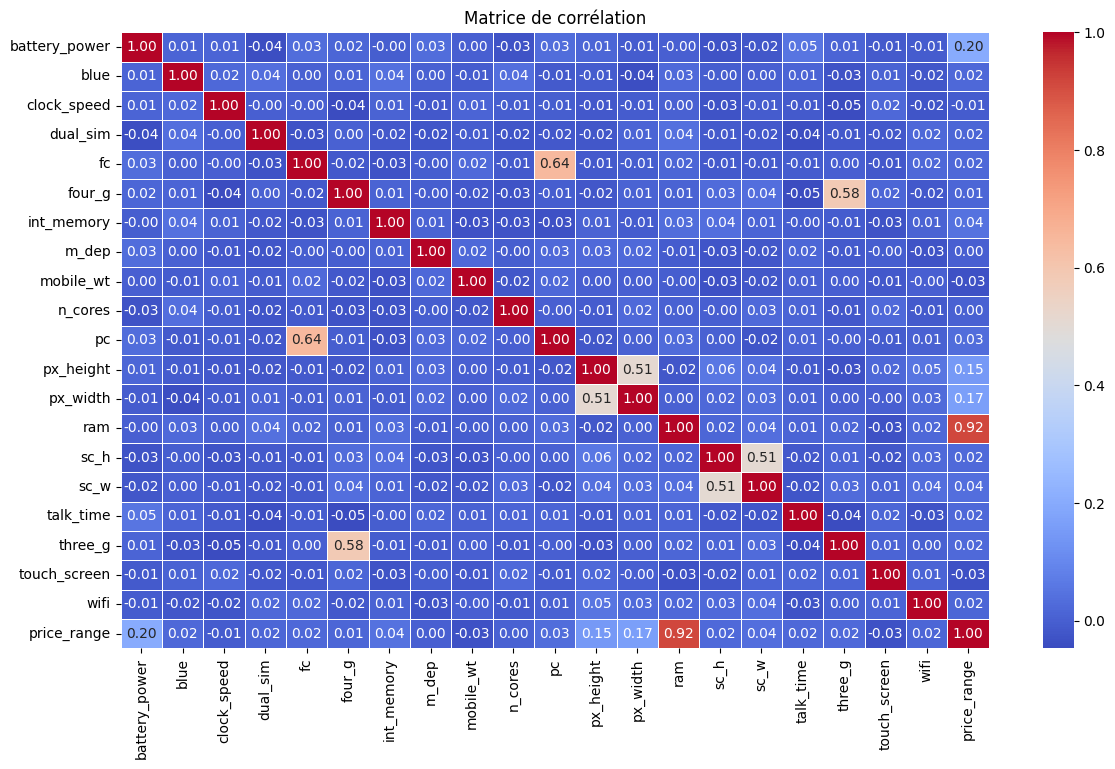

In [17]:
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(), cmap='coolwarm', fmt=".2f", linewidths=0.5, annot=True)
plt.title("Matrice de corrélation")
plt.show()

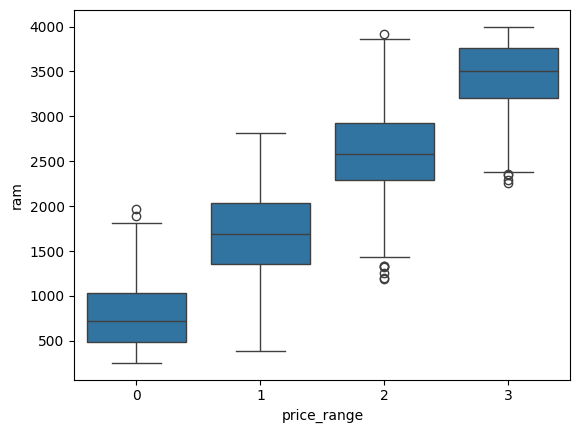

In [18]:
sns.boxplot(x='price_range', y='ram', data=df)
plt.show()

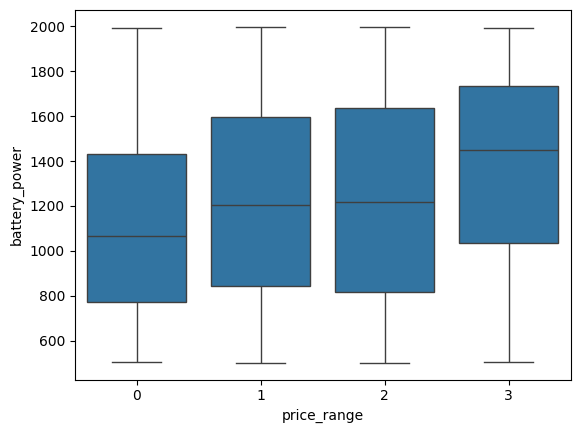

In [19]:
sns.boxplot(x='price_range', y='battery_power', data=df)
plt.show()

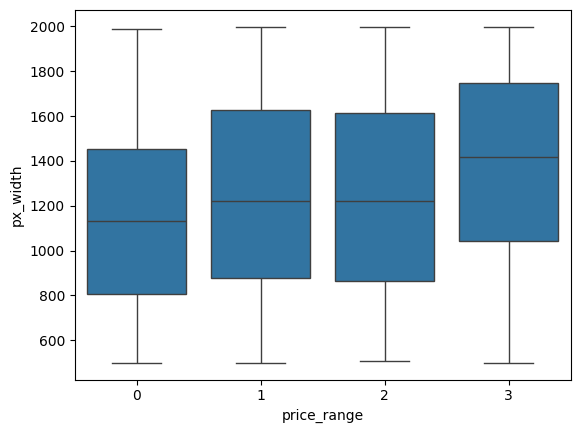

In [20]:
sns.boxplot(x='price_range', y='px_width', data=df)
plt.show()

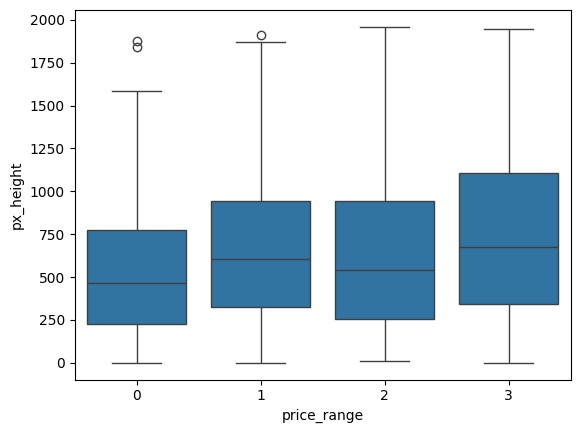

In [21]:
sns.boxplot(x='price_range', y='px_height', data=df)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

#  Création de features dérivées sécurisées

df['px_total'] = df['px_height'] * df['px_width']
df['screen_ratio'] = df['sc_h'] / df['sc_w'].replace(0, np.nan) 
df['screen_ratio'] = df['screen_ratio'].fillna(df['screen_ratio'].median())
df['battery_per_weight'] = df['battery_power'] / df['mobile_wt']

#  Définir colonnes selon type

continuous_cols = ['battery_power', 'ram', 'px_height', 'px_width', 'mobile_wt', 'clock_speed', 'm_dep', 'px_total', 'screen_ratio', 'battery_per_weight']
binary_cols = ['blue','dual_sim','four_g','three_g','touch_screen','wifi']
discrete_cols = ['fc','pc','n_cores','int_memory','sc_h','sc_w','talk_time']

In [23]:
# Séparer features et cible

X = df[continuous_cols + binary_cols + discrete_cols]
y = df['price_range']

#  Split train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
#  Préprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), continuous_cols),  # robuste aux outliers
        ('bin', 'passthrough', binary_cols + discrete_cols)
    ]
)

# Pipeline avec RandomForest

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])


In [25]:
#  GridSearchCV avec validation croisée

param_grid = {
    'classifier__n_estimators': [100, 200, 500],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [26]:
#  Entraînement

grid_search.fit(X_train, y_train)

print("Meilleur score CV :", grid_search.best_score_)
print("Meilleurs paramètres :", grid_search.best_params_)

#  Évaluation sur le jeu de test

y_pred = grid_search.predict(X_test)

print("\nScore sur test :", grid_search.score(X_test, y_test))
print("\nClassification report :\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Meilleur score CV : 0.8943750000000001
Meilleurs paramètres : {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 500}

Score sur test : 0.905

Classification report :
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       100
           1       0.86      0.86      0.86       100
           2       0.85      0.82      0.83       100
           3       0.94      0.96      0.95       100

    accuracy                           0.91       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.91      0.90       400



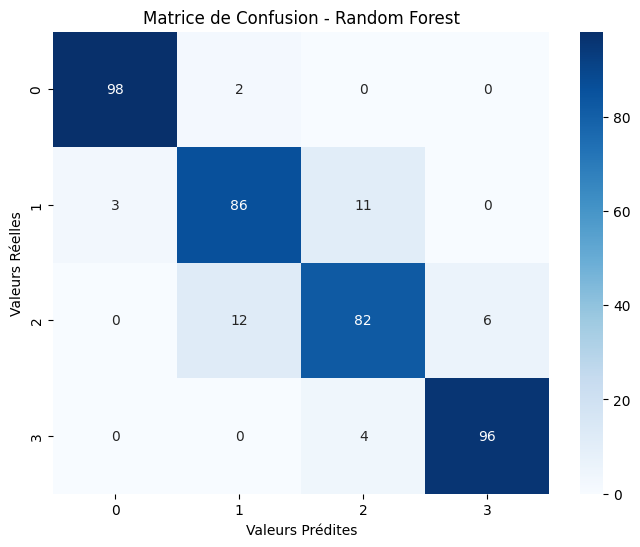

In [27]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel('Valeurs Prédites')
plt.ylabel('Valeurs Réelles')
plt.title('Matrice de Confusion - Random Forest')
plt.show()

C:\Users\jeffr\AppData\Local\Temp\ipykernel_45140\2988441823.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[feature_names[i] for i in indices], y=importances[indices], palette='viridis')


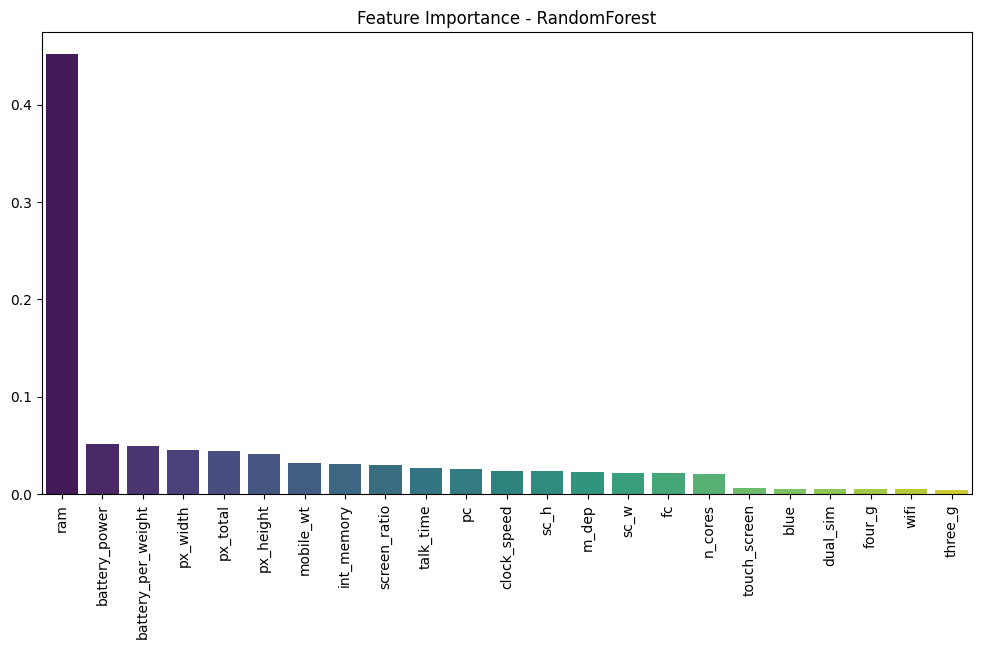

In [28]:
# Feature Importants

best_rf = grid_search.best_estimator_.named_steps['classifier']
feature_names = continuous_cols + binary_cols + discrete_cols
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
sns.barplot(x=[feature_names[i] for i in indices], y=importances[indices], palette='viridis')
plt.xticks(rotation=90)
plt.title("Feature Importance - RandomForest")
plt.show()

In [29]:
from sklearn.svm import SVC

# Pipeline SVM
pipeline_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True, random_state=42))
])

# Grille de paramètres SVM
param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['rbf', 'linear'],
    'classifier__gamma': ['scale', 'auto']
}

In [30]:
# GridSearchCV
grid_search_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Entraînement
grid_search_svm.fit(X_train, y_train)

print("Meilleur score CV (SVM) :", grid_search_svm.best_score_)
print("Meilleurs paramètres (SVM) :", grid_search_svm.best_params_)

# Évaluation test
y_pred_svm = grid_search_svm.predict(X_test)

print("\nScore sur test (SVM) :", grid_search_svm.score(X_test, y_test))
print("\nClassification report (SVM) :\n", classification_report(y_test, y_pred_svm))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Meilleur score CV (SVM) : 0.9568749999999999
Meilleurs paramètres (SVM) : {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}

Score sur test (SVM) : 0.97

Classification report (SVM) :
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       100
           1       0.96      0.96      0.96       100
           2       0.95      0.95      0.95       100
           3       0.98      0.98      0.98       100

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



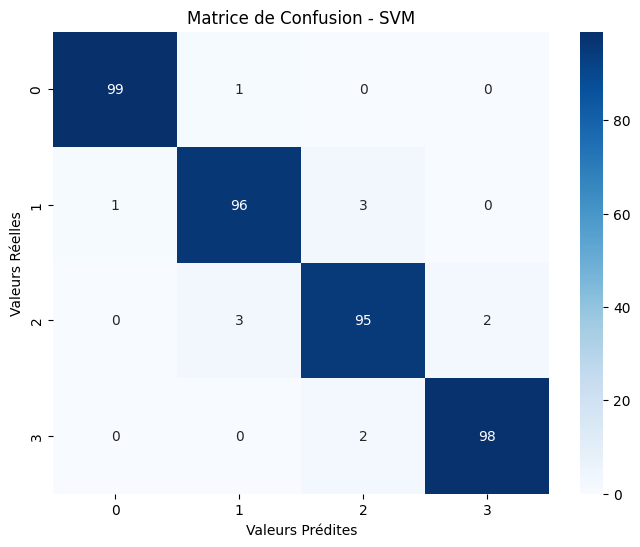

In [31]:
# Matrice de confusion
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel('Valeurs Prédites')
plt.ylabel('Valeurs Réelles')
plt.title('Matrice de Confusion - SVM')
plt.show()

In [32]:
from sklearn.neighbors import KNeighborsClassifier

# Pipeline KNN
pipeline_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# Grille de paramètres KNN
param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['minkowski', 'euclidean']
}

In [33]:
# GridSearchCV
grid_search_knn = GridSearchCV(
    pipeline_knn,
    param_grid_knn,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Entraînement
grid_search_knn.fit(X_train, y_train)

print("Meilleur score CV (KNN) :", grid_search_knn.best_score_)
print("Meilleurs paramètres (KNN) :", grid_search_knn.best_params_)

# Évaluation test
y_pred_knn = grid_search_knn.predict(X_test)

print("\nScore sur test (KNN) :", grid_search_knn.score(X_test, y_test))
print("\nClassification report (KNN) :\n", classification_report(y_test, y_pred_knn))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Meilleur score CV (KNN) : 0.29625
Meilleurs paramètres (KNN) : {'classifier__metric': 'minkowski', 'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}

Score sur test (KNN) : 0.2775

Classification report (KNN) :
               precision    recall  f1-score   support

           0       0.27      0.32      0.29       100
           1       0.23      0.27      0.25       100
           2       0.30      0.26      0.28       100
           3       0.33      0.26      0.29       100

    accuracy                           0.28       400
   macro avg       0.28      0.28      0.28       400
weighted avg       0.28      0.28      0.28       400



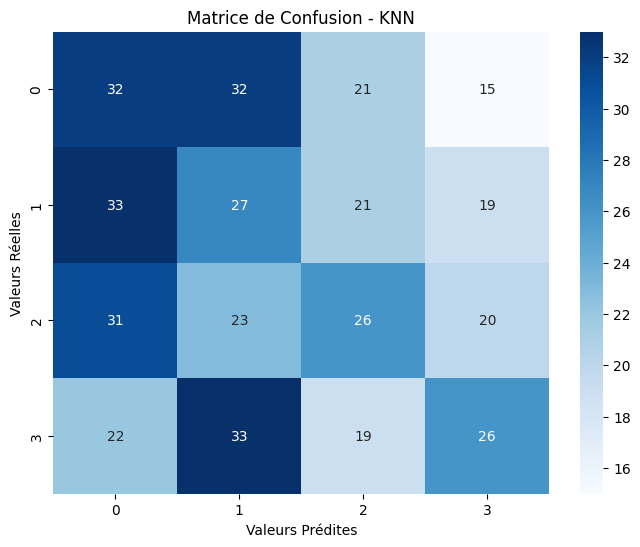

In [34]:
# Matrice de confusion
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel('Valeurs Prédites')
plt.ylabel('Valeurs Réelles')
plt.title('Matrice de Confusion - KNN')
plt.show()

In [35]:
results = pd.DataFrame({
    'Modèle': ['RandomForest', 'SVM', 'KNN'],
    'CV Accuracy': [
        grid_search.best_score_,
        grid_search_svm.best_score_,
        grid_search_knn.best_score_
    ],
    'Test Accuracy': [
        grid_search.score(X_test, y_test),
        grid_search_svm.score(X_test, y_test),
        grid_search_knn.score(X_test, y_test)
    ]
})

print(results)

         Modèle  CV Accuracy  Test Accuracy
0  RandomForest     0.894375         0.9050
1           SVM     0.956875         0.9700
2           KNN     0.296250         0.2775


In [36]:
from sklearn.model_selection import learning_curve

# Sélection du meilleur modèle selon la CV Accuracy
best_row = results.loc[results['CV Accuracy'].idxmax()]
best_model_name = best_row['Modèle']

print("Meilleur modèle selon la validation croisée :", best_model_name)
print(best_row)


Meilleur modèle selon la validation croisée : SVM
Modèle                SVM
CV Accuracy      0.956875
Test Accuracy        0.97
Name: 1, dtype: object


In [37]:
if best_model_name == 'RandomForest':
    best_model = grid_search.best_estimator_
elif best_model_name == 'SVM':
    best_model = grid_search_svm.best_estimator_
elif best_model_name == 'KNN':
    best_model = grid_search_knn.best_estimator_

In [38]:
from sklearn.model_selection import learning_curve

# Learning Curve du meilleur modèle

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Moyennes et écarts-types
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

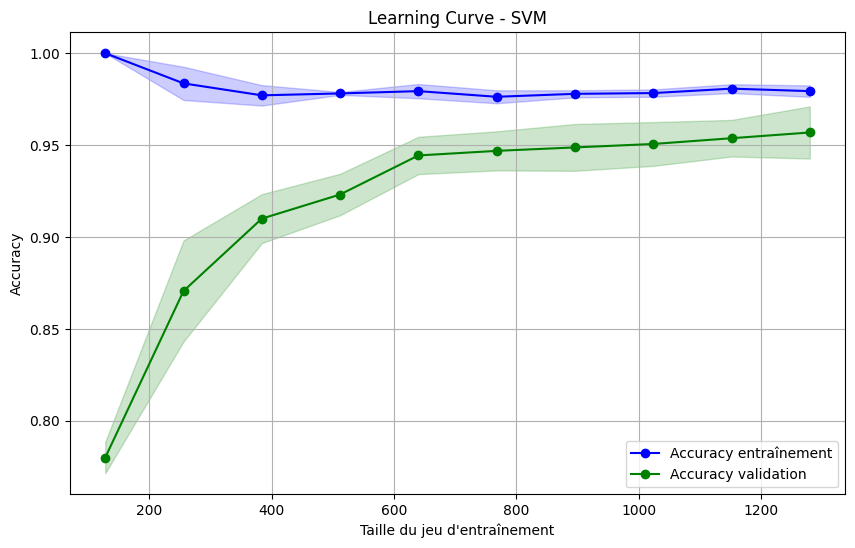

In [39]:
plt.figure(figsize=(10,6))

plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Accuracy entraînement')
plt.plot(train_sizes, val_mean, 'o-', color='green', label='Accuracy validation')

plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2,
                 color='blue')

plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2,
                 color='green')

plt.xlabel("Taille du jeu d'entraînement")
plt.ylabel("Accuracy")
plt.title(f"Learning Curve - {best_model_name}")
plt.legend()
plt.grid(True)
plt.show()

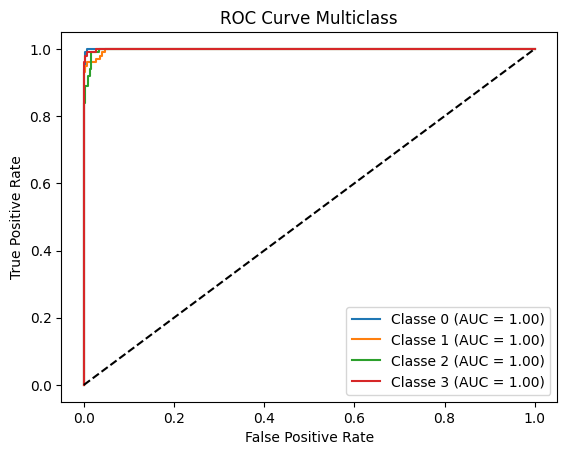

In [40]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
y_score = best_model.predict_proba(X_test)

for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Classe {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Multiclass')
plt.legend()
plt.show()
